# 33 — Depression (CES-D-10) vs Cognition (MoCA)

**Purpose**: NB29–32 mapped the emotional side of diabetes — depression (CES-D-10) and
diabetes distress (PAID-5). This notebook turns to **cognition**: the MoCA (Montreal Cognitive
Assessment) screens for cognitive impairment. The question: **does depression track with worse
cognition in this cohort — overall, within diabetes groups and age bands, across MoCA
subdomains, and after adjusting for age?**

**Why this matters**: Depression and cognitive impairment co-occur ("depressive
pseudodementia"), and both are elevated in diabetes. But cognition is dominated by age, so a
raw correlation can hide — or fake — a depression effect. This notebook separates the two.

**Direction note**: CES-D-10 is scored so **higher = more depressed**; MoCA is scored so
**higher = better cognition** (< 26 = impairment). A genuine depression–cognition link should
therefore appear as a **negative** correlation.

**Self-contained**: Loads directly from Azure — no dependency on prior notebook outputs.

**Inputs**:
- Azure `{STUDY_ID}/dataset/participants.tsv` — study group labels
- Azure `{STUDY_ID}/dataset/clinical_data/person.csv` — year_of_birth → age
- Azure `{STUDY_ID}/dataset/clinical_data/observation.csv` — CES-D-10 (`cestl`)
- Azure `{STUDY_ID}/dataset/clinical_data/measurement.csv` — MoCA total + subdomains

---

**Table of Contents**
1. Environment Setup
2. Azure Connection & Data Load
3. Build CES-D-10 + MoCA Master DataFrame
4. Analysis 1 — Overall Correlation & Distributions
5. Analysis 2 — By Diabetes Group (+ impairment by severity)
6. Analysis 3 — By Age Band
7. Analysis 4 — MoCA Subdomains vs Depression
8. Analysis 5 — Age-Adjusted Regression: Does Depression Independently Predict Cognition?
9. Key Findings

---

In [1]:
# ── 1. Environment Setup ────────────────────────────────────────────
import subprocess, sys

for pkg in ['azure-storage-blob', 'seaborn', 'scipy', 'python-dotenv', 'statsmodels']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'],
                   capture_output=True, text=True)

import os, re, warnings, getpass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
from io import StringIO
from scipy.stats import kruskal, mannwhitneyu, spearmanr, chi2_contingency
from statsmodels.stats.multitest import multipletests
import statsmodels.formula.api as smf
import statsmodels.api as sm

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.3f}'.format)

STUDY_GROUP_ORDER   = ['Healthy', 'Pre-DM', 'Oral Med', 'Insulin']
STUDY_GROUP_MAP     = {0: 'Healthy', 1: 'Pre-DM', 2: 'Oral Med', 3: 'Insulin'}
STUDY_GROUP_STR_MAP = {
    'healthy': 0, 'prediabetes': 1, 'pre-diabetes': 1, 'pre_diabetes': 1,
    'oral medication': 2, 'oral_medication': 2, 'non-insulin': 2,
    'insulin': 3, 'insulin-dependent': 3,
    'pre_diabetes_lifestyle_controlled': 1,
    'oral_medication_and_or_non_insulin_injectable_medication_controlled': 2,
    'insulin_dependent': 3,
}
GROUP_COLORS = {'Healthy': '#66C2A5', 'Pre-DM': '#4DAFFA', 'Oral Med': '#F5A623', 'Insulin': '#E8413E'}

AGE_BAND_EDGES  = [0, 50, 60, 70, 120]
AGE_BAND_LABELS = ['<50', '50–59', '60–69', '70+']

DEPRESSION_CUTOFF      = 10   # CES-D-10 ≥ 10  = probable depression
MOCA_IMPAIRMENT_CUTOFF = 26   # MoCA     < 26  = cognitive impairment

# MoCA measures (higher = better cognition)
MOCA_SUBDOMAINS = {
    'moca_total_score':        'MoCA Total (0–30)',
    'moca_orientation':        'Orientation (0–6)',
    'moca_combined_mis_score': 'Memory Index (0–15)',
    'moca_abstraction':        'Abstraction (0–2)',
}

STUDY_ID = '1438dd73-c4cb-48b8-8fa8-c858771207c3'

print('Environment ready.')

Environment ready.


In [2]:
# ── 2. Azure Connection & Data Load ───────────────────────────────
from azure.storage.blob import BlobServiceClient
from dotenv import load_dotenv

IN_COLAB = os.path.exists('/content')

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    CONNECTION_STRING = getpass.getpass('CONNECTION_STRING: ')
    CONTAINER_NAME = 'aireadi-container'
else:
    _cwd = Path.cwd()
    if (_cwd / 'config' / 'azure_config.py').exists():
        repo_root = str(_cwd)
    elif (_cwd.parent / 'config' / 'azure_config.py').exists():
        repo_root = str(_cwd.parent)
    else:
        repo_root = str(_cwd)

    _env_path = Path(repo_root) / '.env'
    load_dotenv(_env_path, override=True)
    CONNECTION_STRING = os.getenv('AZURE_STORAGE_CONNECTION_STRING', '')
    CONTAINER_NAME    = os.getenv('AZURE_CONTAINER_NAME', 'aireadi-container')
    STUDY_ID          = os.getenv('AZURE_STUDY_ID', STUDY_ID)
    print(f'.env found={_env_path.exists()}  |  repo_root={repo_root}')
    if not CONNECTION_STRING:
        raise ValueError('AZURE_STORAGE_CONNECTION_STRING empty — check .env')

blob_svc  = BlobServiceClient.from_connection_string(CONNECTION_STRING)
container = blob_svc.get_container_client(CONTAINER_NAME)

def load_blob_csv(blob_path, sep=',', **kwargs):
    bc   = container.get_blob_client(blob_path)
    data = bc.download_blob().readall().decode('utf-8')
    return pd.read_csv(StringIO(data), sep=sep, low_memory=False, **kwargs)

print('\nLoading participants.tsv ...')
participants = load_blob_csv(f'{STUDY_ID}/dataset/participants.tsv', sep='\t')
sg_col = next((c for c in participants.columns if 'study' in c.lower()), None)
participants['study_group_code']  = (participants[sg_col].str.lower()
                                     .str.strip().map(STUDY_GROUP_STR_MAP))
participants['study_group_label'] = participants['study_group_code'].map(STUDY_GROUP_MAP)
participants['study_group_label'] = pd.Categorical(
    participants['study_group_label'], categories=STUDY_GROUP_ORDER, ordered=True)
print(f'  {len(participants):,} participants')
print(participants['study_group_label'].value_counts().sort_index().to_string())

print('\nLoading person.csv ...')
person = load_blob_csv(f'{STUDY_ID}/dataset/clinical_data/person.csv',
                       usecols=['person_id', 'year_of_birth'])
person['age'] = 2024 - person['year_of_birth']

print('\nLoading observation.csv (CES-D-10) ...')
obs_raw = load_blob_csv(f'{STUDY_ID}/dataset/clinical_data/observation.csv',
                        usecols=['person_id', 'observation_source_value', 'value_as_number'])
print(f'  {len(obs_raw):,} rows')

print('\nLoading measurement.csv (MoCA) ...')
meas_raw = load_blob_csv(f'{STUDY_ID}/dataset/clinical_data/measurement.csv',
                         usecols=['person_id', 'measurement_source_value', 'value_as_number'])
print(f'  {len(meas_raw):,} rows')

.env found=True  |  repo_root=/Users/evanlee/Desktop/ucsf-tech-aireadi

Loading participants.tsv ...
  2,280 participants
study_group_label
Healthy     776
Pre-DM      560
Oral Med    686
Insulin     258

Loading person.csv ...

Loading observation.csv (CES-D-10) ...
  707,126 rows

Loading measurement.csv (MoCA) ...
  242,279 rows


In [3]:
# ── 3. Build CES-D-10 + MoCA Master DataFrame ─────────────────────
# CES-D-10 total (observation `cestl`)
obs_raw['item_key']    = (obs_raw['observation_source_value'].astype(str)
                          .str.split(',', n=1).str[0].str.strip().str.lower())
obs_raw['value_clean'] = pd.to_numeric(obs_raw['value_as_number'], errors='coerce')
obs_raw.loc[obs_raw['value_clean'] == 99, 'value_clean'] = np.nan
cesd_total = (obs_raw[obs_raw['item_key'] == 'cestl']
              .groupby('person_id')['value_clean'].first().rename('cesd_total'))

# MoCA total + subdomains (measurement.csv)
meas_raw['mkey'] = meas_raw['measurement_source_value'].astype(str).str.strip().str.lower()
meas_raw['mval'] = pd.to_numeric(meas_raw['value_as_number'], errors='coerce')
MOCA_COLS = list(MOCA_SUBDOMAINS.keys())
moca_wide = (meas_raw[meas_raw['mkey'].isin(MOCA_COLS)]
             .pivot_table(index='person_id', columns='mkey', values='mval', aggfunc='first'))

# Merge
df = (participants[['person_id', 'study_group_code', 'study_group_label']]
      .merge(person[['person_id', 'age']], on='person_id', how='left')
      .merge(cesd_total.reset_index(),      on='person_id', how='left')
      .merge(moca_wide.reset_index(),       on='person_id', how='left'))

df['study_group_label'] = pd.Categorical(
    df['study_group_label'], categories=STUDY_GROUP_ORDER, ordered=True)
df['age_band'] = pd.cut(df['age'], bins=AGE_BAND_EDGES, labels=AGE_BAND_LABELS, right=False)
df['age_band'] = pd.Categorical(df['age_band'], categories=AGE_BAND_LABELS, ordered=True)
df['age_std']  = (df['age'] - df['age'].mean()) / df['age'].std()

df['depressed']     = (df['cesd_total'] >= DEPRESSION_CUTOFF).astype('float')
df['moca_impaired'] = (df['moca_total_score'] < MOCA_IMPAIRMENT_CUTOFF).astype('float')

MOCA_AVAILABLE = [c for c in MOCA_COLS if c in df.columns]

print(f'Final df: {df.shape[0]:,} rows × {df.shape[1]} cols')
print(f'CES-D-10:   {df["cesd_total"].notna().sum():,} scored '
      f'(depressed ≥{DEPRESSION_CUTOFF}: {df["depressed"].mean()*100:.1f}%)')
print(f'MoCA total: {df["moca_total_score"].notna().sum():,} scored '
      f'(mean {df["moca_total_score"].mean():.1f}/30, '
      f'impaired <{MOCA_IMPAIRMENT_CUTOFF}: {df["moca_impaired"].mean()*100:.1f}%)')
print(f'Both scores present: {df.dropna(subset=["cesd_total","moca_total_score"]).shape[0]:,}')
print(f'MoCA measures found: {MOCA_AVAILABLE}')

Final df: 2,280 rows × 13 cols
CES-D-10:   2,277 scored (depressed ≥10: 20.0%)
MoCA total: 2,265 scored (mean 25.6/30, impaired <26: 40.7%)
Both scores present: 2,262
MoCA measures found: ['moca_total_score', 'moca_orientation', 'moca_combined_mis_score', 'moca_abstraction']


---
## 4. Analysis 1 — Overall Correlation & Distributions

> **Question**: Across the full cohort, does depression (CES-D-10) correlate with cognition
> (MoCA total)? Remember the expected direction is **negative** — more depression should mean
> lower MoCA.
>
> **Method**: Spearman and Pearson correlation between CES-D-10 and MoCA total, the MoCA score
> distribution against the impairment cutoff, and a scatter with trend line.

=== CES-D-10 (depression) vs MoCA total (cognition) — Overall ===
  n with both scores : 2,262
  Spearman rho       : -0.033  (p = 1.202e-01)
  Pearson  r         : -0.068
  (negative = more depression -> lower cognition)

  MoCA total : mean 25.6/30  | impaired (<26): 40.8%
  CES-D-10   : mean 5.84/30  | depressed (≥10): 19.9%


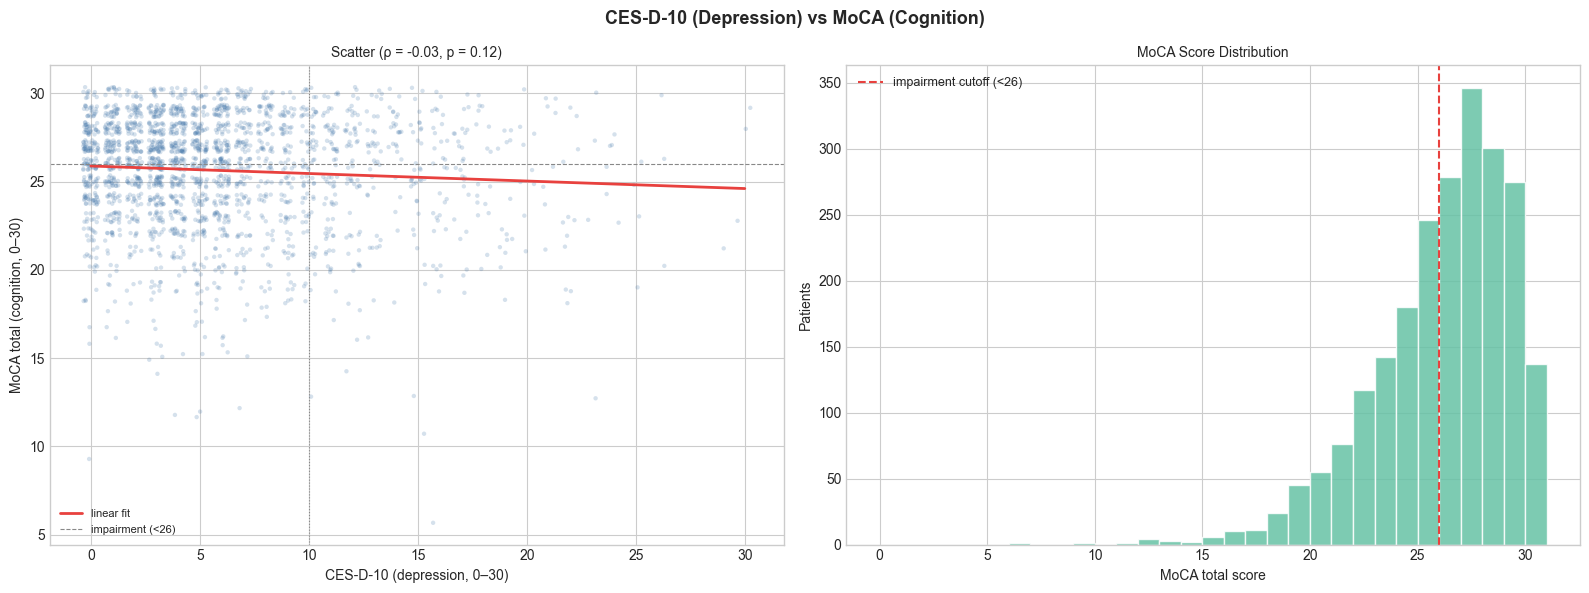

In [4]:
# ── Analysis 1: Overall Correlation & Distributions ───────────────
both = df.dropna(subset=['cesd_total', 'moca_total_score']).copy()

rho, p_rho = spearmanr(both['cesd_total'], both['moca_total_score'])
r_pear     = both['cesd_total'].corr(both['moca_total_score'])

print('=== CES-D-10 (depression) vs MoCA total (cognition) — Overall ===')
print(f'  n with both scores : {len(both):,}')
print(f'  Spearman rho       : {rho:+.3f}  (p = {p_rho:.3e})')
print(f'  Pearson  r         : {r_pear:+.3f}')
print(f'  (negative = more depression -> lower cognition)')
print()
print(f'  MoCA total : mean {both["moca_total_score"].mean():.1f}/30  | '
      f'impaired (<{MOCA_IMPAIRMENT_CUTOFF}): {(both["moca_total_score"]<MOCA_IMPAIRMENT_CUTOFF).mean()*100:.1f}%')
print(f'  CES-D-10   : mean {both["cesd_total"].mean():.2f}/30  | '
      f'depressed (≥{DEPRESSION_CUTOFF}): {(both["cesd_total"]>=DEPRESSION_CUTOFF).mean()*100:.1f}%')

# ── Visualisation ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('CES-D-10 (Depression) vs MoCA (Cognition)', fontsize=13, fontweight='bold')

# Panel A: scatter with jitter + linear trend
rng = np.random.default_rng(0)
jx = both['cesd_total']       + rng.uniform(-0.35, 0.35, len(both))
jy = both['moca_total_score'] + rng.uniform(-0.35, 0.35, len(both))
axes[0].scatter(jx, jy, s=10, alpha=0.22, color='#4477AA', edgecolors='none')
z  = np.polyfit(both['cesd_total'], both['moca_total_score'], 1)
xs = np.linspace(0, both['cesd_total'].max(), 50)
axes[0].plot(xs, z[0]*xs + z[1], color='#E8413E', linewidth=2, label='linear fit')
axes[0].axhline(MOCA_IMPAIRMENT_CUTOFF, color='#888', linestyle='--', linewidth=0.8,
                label=f'impairment (<{MOCA_IMPAIRMENT_CUTOFF})')
axes[0].axvline(DEPRESSION_CUTOFF, color='#888', linestyle=':', linewidth=0.8)
axes[0].set_xlabel('CES-D-10 (depression, 0–30)')
axes[0].set_ylabel('MoCA total (cognition, 0–30)')
axes[0].set_title(f'Scatter (ρ = {rho:+.2f}, p = {p_rho:.2f})', fontsize=10)
axes[0].legend(fontsize=8)

# Panel B: MoCA distribution with impairment cutoff
axes[1].hist(both['moca_total_score'], bins=range(0, 32, 1), color='#66C2A5',
             edgecolor='white', alpha=0.85)
axes[1].axvline(MOCA_IMPAIRMENT_CUTOFF, color='#E8413E', linestyle='--', linewidth=1.5,
                label=f'impairment cutoff (<{MOCA_IMPAIRMENT_CUTOFF})')
axes[1].set_xlabel('MoCA total score')
axes[1].set_ylabel('Patients')
axes[1].set_title('MoCA Score Distribution', fontsize=10)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 5. Analysis 2 — By Diabetes Group (and Impairment by Severity)

> **Question**: Does the depression–cognition link differ by diabetes severity? And separately —
> does cognitive impairment itself become more common in sicker groups, even if its *correlation*
> with depression is weak?
>
> **Method**: Spearman (CES-D-10 vs MoCA total) within each study group, FDR-corrected, plus each
> group's mean MoCA and impairment rate. Kruskal-Wallis tests whether MoCA differs across groups.

=== CES-D-10 vs MoCA correlation within each diabetes group ===
   group   n    rho  p_fdr  significant  moca_mean  impaired_%
 Healthy 773  0.054  0.254        False     26.100      33.800
  Pre-DM 555 -0.030  0.478        False     25.900      37.300
Oral Med 680 -0.050  0.254        False     25.400      45.600
 Insulin 254 -0.091  0.254        False     24.300      57.500

Kruskal-Wallis (MoCA total across groups): H=61.99, p=2.203e-13


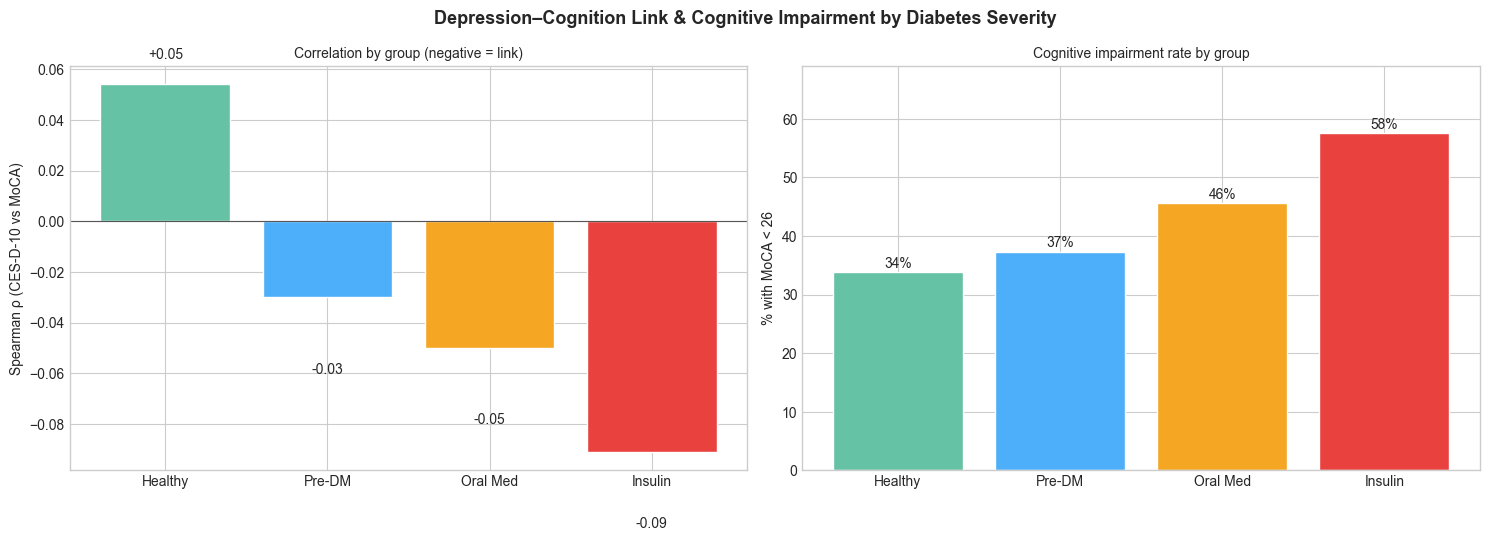

In [5]:
# ── Analysis 2: By Diabetes Group (+ impairment by severity) ──────
rows = []
for g in STUDY_GROUP_ORDER:
    s = both[both['study_group_label'] == g]
    if len(s) < 10:
        continue
    rho_g, p_g = spearmanr(s['cesd_total'], s['moca_total_score'])
    rows.append({'group': g, 'n': len(s), 'rho': round(rho_g, 3), 'p': p_g,
                 'moca_mean': round(s['moca_total_score'].mean(), 1),
                 'impaired_%': round((s['moca_total_score'] < MOCA_IMPAIRMENT_CUTOFF).mean()*100, 1)})
g_df = pd.DataFrame(rows)
_, g_df['p_fdr'], _, _ = multipletests(g_df['p'], method='fdr_bh')
g_df['p_fdr'] = g_df['p_fdr'].round(4)
g_df['significant'] = g_df['p_fdr'] < 0.05

print('=== CES-D-10 vs MoCA correlation within each diabetes group ===')
print(g_df[['group', 'n', 'rho', 'p_fdr', 'significant', 'moca_mean', 'impaired_%']].to_string(index=False))

# Does MoCA itself differ across groups?
grps = [both[both['study_group_label'] == g]['moca_total_score'].dropna() for g in STUDY_GROUP_ORDER]
H, p_kw = kruskal(*grps)
print(f'\nKruskal-Wallis (MoCA total across groups): H={H:.2f}, p={p_kw:.3e}')

# ── Visualisation ──
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig.suptitle('Depression–Cognition Link & Cognitive Impairment by Diabetes Severity',
             fontsize=13, fontweight='bold')

# Panel A: rho per group
bar_colors = [GROUP_COLORS[g] for g in g_df['group']]
bars = axes[0].bar(g_df['group'], g_df['rho'], color=bar_colors, edgecolor='white')
for bar, r, sig in zip(bars, g_df['rho'], g_df['significant']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 r + (0.01 if r >= 0 else -0.03),
                 f'{r:+.2f}{"*" if sig else ""}', ha='center', fontsize=10)
axes[0].axhline(0, color='#555', linewidth=0.8)
axes[0].set_ylabel('Spearman ρ (CES-D-10 vs MoCA)')
axes[0].set_title('Correlation by group (negative = link)', fontsize=10)

# Panel B: impairment rate per group (the severity gradient)
bars2 = axes[1].bar(g_df['group'], g_df['impaired_%'], color=bar_colors, edgecolor='white')
for bar, v in zip(bars2, g_df['impaired_%']):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.8, f'{v:.0f}%', ha='center', fontsize=10)
axes[1].set_ylabel(f'% with MoCA < {MOCA_IMPAIRMENT_CUTOFF}')
axes[1].set_title('Cognitive impairment rate by group', fontsize=10)
axes[1].set_ylim(0, max(g_df['impaired_%']) * 1.2)

plt.tight_layout()
plt.show()

---
### Bootstrap robustness check — accounting for class imbalance

> The per-group correlation between depression and cognition rests on unequal samples
> (**Insulin n≈254 vs Healthy n≈773**). Here we resample each group **with replacement** (5,000×)
> for a 95% confidence interval around the Spearman ρ. **A CI entirely below 0 would confirm a real
> depression→worse-cognition link in that group; a CI spanning 0 means we can't distinguish it from
> no relationship.** Bootstrap keeps each group at its *own* size (it does not equalize them) and
> uses real patients, not synthetic ones.

In [6]:
# ── Bootstrap 95% CIs for per-group CES-D-10 vs MoCA Spearman ρ (real patients) ──
def bootstrap_corr_ci(x, y, n_boot=5000, seed=0):
    x = np.asarray(x, float); y = np.asarray(y, float); n = x.size
    rng = np.random.default_rng(seed)
    boots = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, n)
        boots[i] = spearmanr(x[idx], y[idx]).correlation
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return spearmanr(x, y).correlation, lo, hi

rows = []
for grp in STUDY_GROUP_ORDER:
    s = both[both['study_group_label'] == grp][['cesd_total', 'moca_total_score']].dropna()
    if len(s) < 20:
        continue
    rho, lo, hi = bootstrap_corr_ci(s['cesd_total'].values, s['moca_total_score'].values)
    rows.append({'group': grp, 'n': len(s), 'rho': round(rho, 3),
                 'ci_low': round(lo, 3), 'ci_high': round(hi, 3),
                 'ci_width': round(hi - lo, 3),
                 'CI_excludes_0': (lo > 0) or (hi < 0)})
boot_df = pd.DataFrame(rows)
print('=== Bootstrap 95% CI for CES-D-10 vs MoCA Spearman ρ by group (real patients) ===')
print('(negative = more depression -> lower cognition; CI spanning 0 = not distinguishable from no link)\n')
print(boot_df.to_string(index=False))
n_robust = int(boot_df['CI_excludes_0'].sum())
print(f'\n{n_robust} of {len(boot_df)} groups have a 95% CI excluding 0 '
      f'(consistent with the weak/near-zero raw correlation seen overall).')

=== Bootstrap 95% CI for CES-D-10 vs MoCA Spearman ρ by group (real patients) ===
(negative = more depression -> lower cognition; CI spanning 0 = not distinguishable from no link)

   group   n    rho  ci_low  ci_high  ci_width  CI_excludes_0
 Healthy 773  0.054  -0.019    0.125     0.144          False
  Pre-DM 555 -0.030  -0.114    0.049     0.163          False
Oral Med 680 -0.050  -0.123    0.027     0.150          False
 Insulin 254 -0.091  -0.214    0.029     0.243          False

0 of 4 groups have a 95% CI excluding 0 (consistent with the weak/near-zero raw correlation seen overall).


---
## 6. Analysis 3 — By Age Band

> **Question**: Cognition is dominated by age. Within each age band (holding age roughly
> constant), does depression correlate with cognition? The link may be visible in younger
> patients but washed out by age in the oldest.
>
> **Method**: Spearman (CES-D-10 vs MoCA total) within each age band, FDR-corrected, with each
> band's mean MoCA.

=== CES-D-10 vs MoCA correlation within each age band ===
age_band   n    rho  p_fdr  significant  moca_mean  impaired_%
     <50 419 -0.099  0.084        False     26.400      30.500
   50–59 560 -0.132  0.007         True     25.900      36.600
   60–69 711 -0.066  0.103        False     25.600      41.200
     70+ 572 -0.010  0.819        False     24.800      52.100


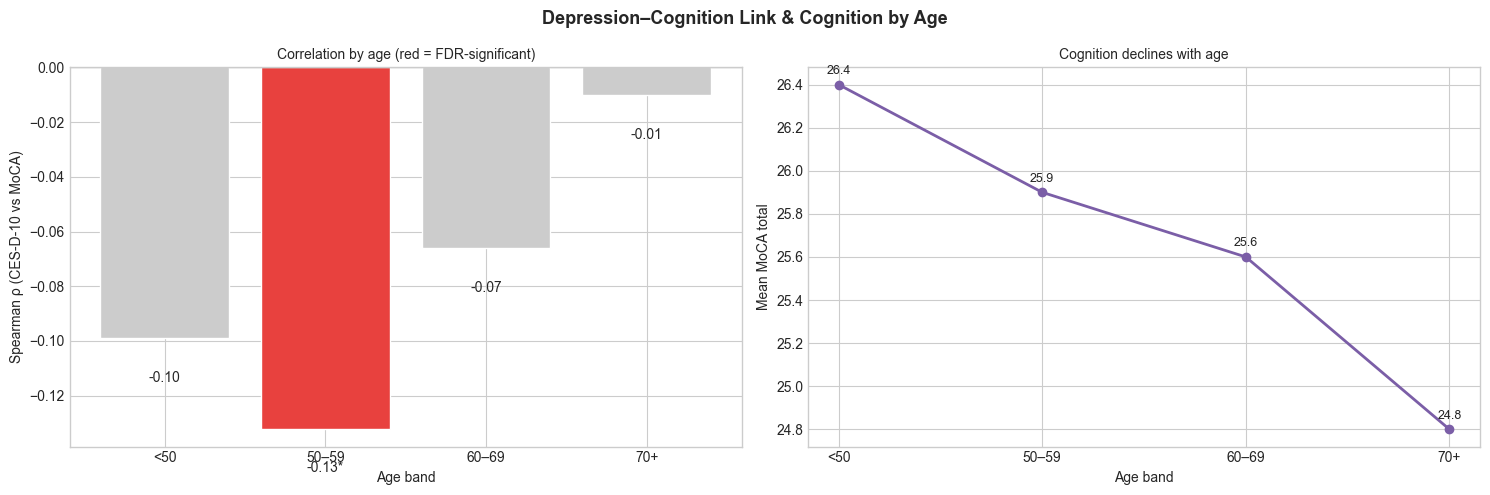

In [7]:
# ── Analysis 3: By Age Band ───────────────────────────────────────
rows = []
for b in AGE_BAND_LABELS:
    s = both[both['age_band'] == b]
    if len(s) < 10:
        continue
    rho_b, p_b = spearmanr(s['cesd_total'], s['moca_total_score'])
    rows.append({'age_band': b, 'n': len(s), 'rho': round(rho_b, 3), 'p': p_b,
                 'moca_mean': round(s['moca_total_score'].mean(), 1),
                 'impaired_%': round((s['moca_total_score'] < MOCA_IMPAIRMENT_CUTOFF).mean()*100, 1)})
a_df = pd.DataFrame(rows)
_, a_df['p_fdr'], _, _ = multipletests(a_df['p'], method='fdr_bh')
a_df['p_fdr'] = a_df['p_fdr'].round(4)
a_df['significant'] = a_df['p_fdr'] < 0.05

print('=== CES-D-10 vs MoCA correlation within each age band ===')
print(a_df[['age_band', 'n', 'rho', 'p_fdr', 'significant', 'moca_mean', 'impaired_%']].to_string(index=False))

# ── Visualisation ──
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Depression–Cognition Link & Cognition by Age', fontsize=13, fontweight='bold')

# Panel A: rho per age band
colors = ['#E8413E' if s else '#cccccc' for s in a_df['significant']]
bars = axes[0].bar(a_df['age_band'], a_df['rho'], color=colors, edgecolor='white')
for bar, r, sig in zip(bars, a_df['rho'], a_df['significant']):
    axes[0].text(bar.get_x() + bar.get_width()/2, r - 0.012,
                 f'{r:+.2f}{"*" if sig else ""}', ha='center', va='top', fontsize=10)
axes[0].axhline(0, color='#555', linewidth=0.8)
axes[0].set_ylabel('Spearman ρ (CES-D-10 vs MoCA)')
axes[0].set_xlabel('Age band')
axes[0].set_title('Correlation by age (red = FDR-significant)', fontsize=10)

# Panel B: mean MoCA by age band (the age effect)
axes[1].plot(a_df['age_band'], a_df['moca_mean'], marker='o', color='#7B5EA7', linewidth=2)
for x, y in zip(a_df['age_band'], a_df['moca_mean']):
    axes[1].text(x, y + 0.05, f'{y:.1f}', ha='center', fontsize=9)
axes[1].set_ylabel('Mean MoCA total')
axes[1].set_xlabel('Age band')
axes[1].set_title('Cognition declines with age', fontsize=10)

plt.tight_layout()
plt.show()

---
## 7. Analysis 4 — MoCA Subdomains vs Depression

> **Question**: Even if global MoCA barely moves with depression, a *specific* cognitive domain
> might. Depression is classically linked to attention/executive function. Which MoCA subdomain —
> orientation, memory (delayed recall), or abstraction — tracks depression most?
>
> **Method**: Spearman correlation between CES-D-10 and each MoCA subdomain, FDR-corrected, ranked.

=== Each MoCA subdomain vs CES-D-10 (Spearman; negative = link to depression) ===
              label   mean  rho_with_cesd  p_fdr  significant    n
  Abstraction (0–2)  1.880         -0.079  0.001         True 2262
Memory Index (0–15) 12.550         -0.035  0.160        False 2262
  MoCA Total (0–30) 25.620         -0.033  0.160        False 2262
  Orientation (0–6)  5.900         -0.023  0.276        False 2262


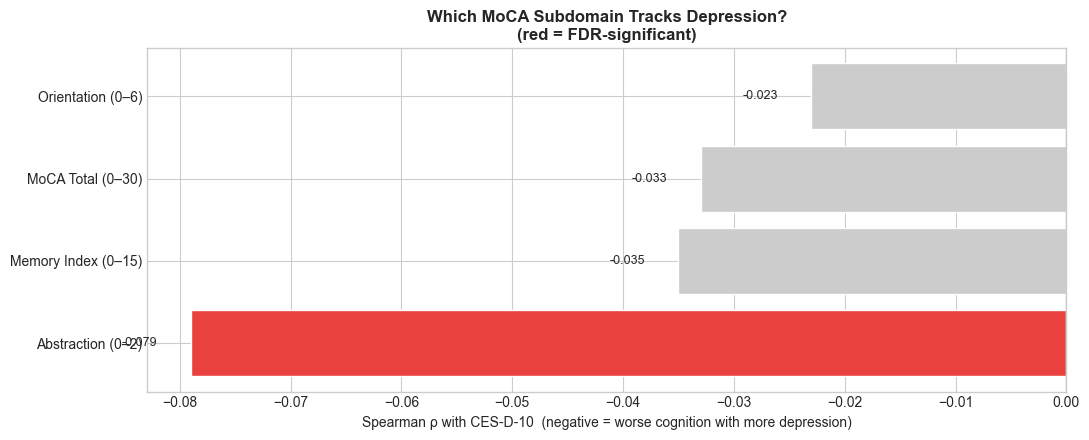

In [8]:
# ── Analysis 4: MoCA Subdomains vs Depression ─────────────────────
rows = []
for k in MOCA_AVAILABLE:
    s = df.dropna(subset=['cesd_total', k])
    if len(s) < 10:
        continue
    rho_i, p_i = spearmanr(s['cesd_total'], s[k])
    rows.append({'subdomain': k, 'label': MOCA_SUBDOMAINS[k],
                 'mean': round(df[k].mean(), 2),
                 'rho_with_cesd': round(rho_i, 3), 'p': p_i, 'n': len(s)})
sd = pd.DataFrame(rows)
_, sd['p_fdr'], _, _ = multipletests(sd['p'], method='fdr_bh')
sd['p_fdr'] = sd['p_fdr'].round(4)
sd['significant'] = sd['p_fdr'] < 0.05
sd = sd.sort_values('rho_with_cesd').reset_index(drop=True)   # most negative first

print('=== Each MoCA subdomain vs CES-D-10 (Spearman; negative = link to depression) ===')
print(sd[['label', 'mean', 'rho_with_cesd', 'p_fdr', 'significant', 'n']].to_string(index=False))

# ── Visualisation ──
fig, ax = plt.subplots(figsize=(11, 4.5))
colors = ['#E8413E' if s else '#cccccc' for s in sd['significant']]
bars = ax.barh(sd['label'], sd['rho_with_cesd'], color=colors, edgecolor='white')
for bar, r in zip(bars, sd['rho_with_cesd']):
    ax.text(r - 0.003, bar.get_y() + bar.get_height()/2, f'{r:+.3f}',
            va='center', ha='right', fontsize=9)
ax.axvline(0, color='#555', linewidth=0.8)
ax.set_xlabel('Spearman ρ with CES-D-10  (negative = worse cognition with more depression)')
ax.set_title('Which MoCA Subdomain Tracks Depression?\n(red = FDR-significant)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Analysis 5 — Age-Adjusted Regression: Does Depression Independently Predict Cognition?

> **Question**: The raw correlation is weak — but age and diabetes severity both drag cognition
> down and could mask a depression effect. After adjusting for age and diabetes group, does
> depression *independently* predict lower MoCA?
>
> **Method**: OLS `moca_total ~ depressed + age_std + study_group_code`. Compare the crude
> depression effect (Model A) to the adjusted one (Model B). A depression coefficient that holds
> up after adjustment means a real, if small, independent cognitive footprint.

n = 2,265

=== Model A: moca_total ~ depressed (crude) ===
  depressed coef = -0.389  p = 2.058e-02  (R²=0.002)

=== Model B: moca_total ~ depressed + age + diabetes group (adjusted) ===
  R² = 0.067
  depressed (≥10)                 : coef = -0.523  p = 1.603e-03
  age (per SD)                    : coef = -0.606  p = 7.903e-20
  diabetes severity (per step)    : coef = -0.491  p = 1.456e-14

Depression effect on MoCA: crude -0.389 -> adjusted -0.523 points
  -> Depression remains a significant independent predictor of lower cognition after adjustment.


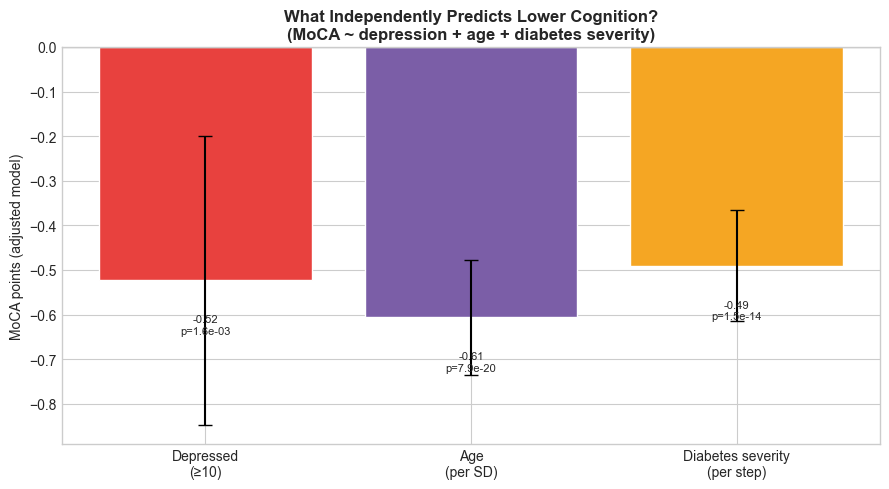

In [9]:
# ── Analysis 5: Age-Adjusted Regression ───────────────────────────
reg = df.dropna(subset=['moca_total_score', 'depressed', 'age_std', 'study_group_code']).copy()

# Model A: crude (depression only)
mod_a = smf.ols('moca_total_score ~ depressed', data=reg).fit()
# Model B: adjusted for age + diabetes group
mod_b = smf.ols('moca_total_score ~ depressed + age_std + study_group_code', data=reg).fit()

print(f'n = {int(mod_b.nobs):,}')
print('\n=== Model A: moca_total ~ depressed (crude) ===')
print(f'  depressed coef = {mod_a.params["depressed"]:+.3f}  p = {mod_a.pvalues["depressed"]:.3e}  '
      f'(R²={mod_a.rsquared:.3f})')

print('\n=== Model B: moca_total ~ depressed + age + diabetes group (adjusted) ===')
print(f'  R² = {mod_b.rsquared:.3f}')
for term, lbl in [('depressed', 'depressed (≥10)'),
                  ('age_std', 'age (per SD)'),
                  ('study_group_code', 'diabetes severity (per step)')]:
    print(f'  {lbl:<32}: coef = {mod_b.params[term]:+.3f}  p = {mod_b.pvalues[term]:.3e}')

_dep_a, _dep_b = mod_a.params['depressed'], mod_b.params['depressed']
print(f'\nDepression effect on MoCA: crude {_dep_a:+.3f} -> adjusted {_dep_b:+.3f} points')
print('  -> ' + (
    'Depression remains a significant independent predictor of lower cognition after adjustment.'
    if mod_b.pvalues['depressed'] < 0.05 else
    'Depression is not an independent predictor once age and severity are controlled.'))

# ── Visualisation ──
fig, ax = plt.subplots(figsize=(9, 5))
terms  = ['depressed', 'age_std', 'study_group_code']
labels = ['Depressed\n(≥10)', 'Age\n(per SD)', 'Diabetes severity\n(per step)']
coefs  = [mod_b.params[t] for t in terms]
errs   = [1.96 * mod_b.bse[t] for t in terms]
colors = ['#E8413E', '#7B5EA7', '#F5A623']
ax.bar(labels, coefs, yerr=errs, color=colors, edgecolor='white', capsize=5)
ax.axhline(0, color='#555', linewidth=0.8)
ax.set_ylabel('MoCA points (adjusted model)')
ax.set_title('What Independently Predicts Lower Cognition?\n(MoCA ~ depression + age + diabetes severity)',
             fontsize=12, fontweight='bold')
for i, (c, t) in enumerate(zip(coefs, terms)):
    ax.text(i, c + (0.05 if c >= 0 else -0.12),
            f'{c:+.2f}\np={mod_b.pvalues[t]:.1e}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

---
## Key Findings

> Numbers below are from the analysis cells above.

**Depression and cognition look unrelated at first glance — but depression leaves a small, real cognitive footprint once age is accounted for. Cognitive impairment itself rises steeply with diabetes severity.**

1. **Overall: essentially no raw correlation** (Analysis 1): CES-D-10 vs MoCA total Spearman ρ = **−0.03 (p ≈ 0.12, not significant)**. At face value, depression and global cognition are decoupled (the small effect only emerges after adjustment — see point 5). Cognitive impairment (MoCA < 26) is common — **~41%** of the cohort.

2. **By diabetes group** (Analysis 2): within-group correlations are all weak and non-significant, with a faint negative drift as severity rises (Healthy +0.05 → Insulin −0.09). But **cognitive impairment scales sharply with severity**: Healthy **34%** → Pre-DM 37% → Oral Med 46% → **Insulin 58%** (Kruskal-Wallis across groups significant). Worse diabetes means worse cognition, even though depression isn't the link.

3. **By age band** (Analysis 3): the correlation is concentrated in **younger** patients — <50: −0.10, 50–59: **−0.13**, 60–69: −0.07, 70+: −0.01 — but after FDR correction only the **50–59 band is significant** (the <50 link is suggestive, raw p≈0.04 → FDR p≈0.08). By 70+ it is essentially zero: age dominates cognition so strongly there that depression's signal washes out.

4. **Subdomains** (Analysis 4): only **abstraction** correlates significantly with depression (ρ = **−0.079**); orientation and memory index do not. The (weak) depression link is concentrated in abstract/executive reasoning, not memory or orientation.

5. **Age-adjusted regression** (Analysis 5): depressed patients score **−0.39 MoCA points** lower even crude (p = 0.02) — and this *strengthens* to **−0.52** after adjusting for age and diabetes group (p = 0.002), so depression is a small but genuine **independent** predictor of lower cognition. Age (−0.61 per SD) and diabetes severity (−0.49 per step) are the larger, independent drivers.

**Key takeaway**: Unlike diabetes distress (NB32), depression and cognition are nearly independent in raw terms — the crude correlation is ~0. But that null hides a small genuine effect: age and diabetes severity dominate cognition, and once they're adjusted for, depression independently predicts slightly lower MoCA. The clinically larger story is that cognitive impairment is widespread and rises steeply with diabetes severity, regardless of mood.